# 02 — V1 Baseline: CTGAN Evaluation

This notebook evaluates the V1 baseline CTGAN model trained on Adult Census Income.

**V1 configuration:**
- Standard CTGAN with `epochs=300`, `batch_size=500`
- No preprocessing transformations on continuous variables
- Trained on 10,000 stratified samples
- 9 categorical columns explicitly declared (enables Mode-Specific Normalization for continuous and Conditional Sampling for discrete)

**Evaluation suite — five complementary metrics:**

| Metric | Measures | Variable type |
|---|---|---|
| Wasserstein distance | Distributional fidelity | Continuous |
| Jensen-Shannon divergence | Distributional fidelity | Categorical |
| Frobenius norm (correlation) | Multivariate structure | Continuous |
| TSTR (Train Synthetic, Test Real) | Predictive utility | Target prediction |
| DCR (Distance to Closest Record) | Memorization risk | All |

The model artifacts (`real_train.csv`, `real_holdout.csv`, `synthetic.csv`) are loaded from `results/v1_baseline/`. They were produced by `run_training.py` in a separate execution (~30 minutes on CPU).

## 1. Setup and Load Artifacts

In [1]:
import sys
from pathlib import Path

# Auto-detect project root
current = Path.cwd()
while current != current.parent:
    if (current / "src" / "config.py").exists():
        project_root = current
        break
    current = current.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import V1_DIR, CONTINUOUS_COLUMNS, CATEGORICAL_COLUMNS
from src.evaluation import (
    compute_wasserstein,
    compute_jsd,
    compute_correlation_difference,
    compute_tstr,
    compute_dcr,
)
from src.visualization import (
    plot_continuous_distributions,
    plot_categorical_distributions,
    plot_correlation_comparison,
)

print(f"Project root: {project_root}")
print(f"V1 artifacts directory: {V1_DIR}")

Project root: c:\Users\Jorge alberto\Documents\Universidades\UNIR\PSU - IA Generativa aplicada a Data\Actividad 1\Codigo Actividad\ctgan-adult-critical-evaluation
V1 artifacts directory: c:\Users\Jorge alberto\Documents\Universidades\UNIR\PSU - IA Generativa aplicada a Data\Actividad 1\Codigo Actividad\ctgan-adult-critical-evaluation\results\v1_baseline


In [2]:
# Load real and synthetic data
df_train = pd.read_csv(V1_DIR / "real_train.csv")
df_holdout = pd.read_csv(V1_DIR / "real_holdout.csv")
synthetic_v1 = pd.read_csv(V1_DIR / "synthetic.csv")

print(f"Real train:    {df_train.shape}")
print(f"Real holdout:  {df_holdout.shape}")
print(f"Synthetic V1:  {synthetic_v1.shape}")

Real train:    (10000, 14)
Real holdout:  (20162, 14)
Synthetic V1:  (10000, 14)


## 2. Synthetic Sample Inspection

Before any metric, a quick visual inspection of synthetic samples to confirm the data is structurally valid (correct columns, expected types, no obvious corruption).

In [3]:
print("First 5 synthetic samples:")
synthetic_v1.head()

First 5 synthetic samples:


,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,44,Private,HS-grad,9,Never-married,Sales,Own-child,White,Male,-43,-1,40,United-States,<=50K
1,54,Private,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,3,0,49,United-States,>50K
2,68,Private,Masters,14,Divorced,Exec-managerial,Unmarried,White,Female,45,0,40,United-States,<=50K
3,25,Private,Bachelors,13,Never-married,Prof-specialty,Not-in-family,Asian-Pac-Islander,Male,-73,0,40,Philippines,<=50K
4,32,Local-gov,10th,6,Never-married,Other-service,Not-in-family,White,Male,-55,-2,40,Puerto-Rico,<=50K


In [4]:
print("Synthetic data types vs real:")
comparison = pd.DataFrame({
    "real": df_train.dtypes.astype(str),
    "synthetic": synthetic_v1.dtypes.astype(str),
})
print(comparison)

Synthetic data types vs real:
                  real synthetic
age              int64     int64
workclass       object    object
education       object    object
education.num    int64     int64
marital.status  object    object
occupation      object    object
relationship    object    object
race            object    object
sex             object    object
capital.gain     int64     int64
capital.loss     int64     int64
hours.per.week   int64     int64
native.country  object    object
income          object    object


## 3. Critical Finding: Logical Validity of Synthetic Values

Before computing any statistical metric, we audit a basic property: do synthetic values respect the **logical domain** of each variable?

For two zero-inflated variables (`capital.gain`, `capital.loss`), the real distribution has a hard lower bound at zero — capital gains and losses cannot be negative by definition. CTGAN, however, models these as continuous variables via Gaussian mixtures, which are unbounded by construction.

We check what fraction of synthetic samples violate this bound.

In [5]:
print("Logical validity audit — proportion of negative values in V1:")
print("-" * 60)

validity_audit = []
for col in ["capital.gain", "capital.loss"]:
    n_neg = (synthetic_v1[col] < 0).sum()
    pct_neg = n_neg / len(synthetic_v1) * 100
    min_val = synthetic_v1[col].min()
    real_min = df_train[col].min()
    
    validity_audit.append({
        "variable": col,
        "n_negative": int(n_neg),
        "pct_negative": round(pct_neg, 2),
        "synthetic_min": float(min_val),
        "real_min": float(real_min),
    })
    
    print(f"\n  {col}:")
    print(f"    Real minimum:       {real_min}")
    print(f"    Synthetic minimum:  {min_val}")
    print(f"    Negative samples:   {n_neg:,} of {len(synthetic_v1):,} ({pct_neg:.2f}%)")

audit_df = pd.DataFrame(validity_audit)

Logical validity audit — proportion of negative values in V1:
------------------------------------------------------------

  capital.gain:
    Real minimum:       0
    Synthetic minimum:  -143
    Negative samples:   6,195 of 10,000 (61.95%)

  capital.loss:
    Real minimum:       0
    Synthetic minimum:  -6
    Negative samples:   3,570 of 10,000 (35.70%)


**This is a structural failure of V1.**

Over 60% of synthetic `capital.gain` values are negative — a value that is impossible by definition. The model technically achieves favorable Wasserstein scores on these variables (as we will see in Section 4), but **half the synthetic dataset contains values that violate the variable's domain**.

This finding has two implications:

1. **Statistical metrics alone are insufficient** for evaluating synthetic data quality. Wasserstein distance is invariant to value validity — it measures distributional distance only. A model that produces 60% logically invalid samples can still achieve favorable Wasserstein scores if the invalid mass is distributed symmetrically around the valid range.

2. **V2 of this experiment was designed to address this exact problem.** By applying `log1p` transformation to compress the heavy positive tail, training CTGAN on the log-scale, and then inverting with `expm1` followed by clipping at zero, V2 ensures that all generated values respect the variable's logical domain.

We will see the V2 result in `03_improved_v2.ipynb`. For now, we proceed with the V1 evaluation as-is — the negative values will not be removed or clipped, because doing so would mask the failure mode we want to document.

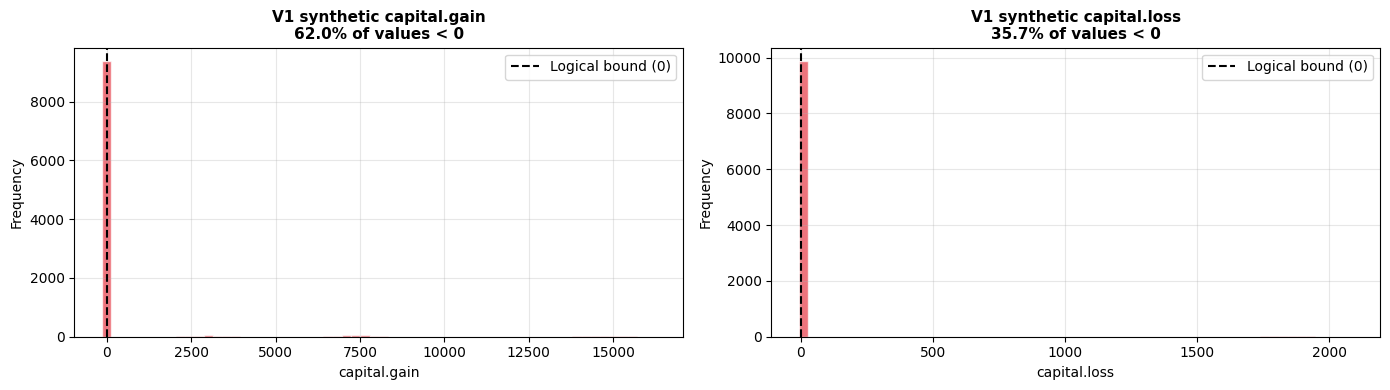

In [6]:
# Visualize: how badly does V1 violate the bound?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, col in enumerate(["capital.gain", "capital.loss"]):
    ax = axes[i]
    ax.hist(synthetic_v1[col], bins=60, color="#E63946", alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="Logical bound (0)")
    pct_neg = (synthetic_v1[col] < 0).mean() * 100
    ax.set_title(f"V1 synthetic {col}\n{pct_neg:.1f}% of values < 0", fontsize=11, weight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Wasserstein Distance — Continuous Variables

Wasserstein distance (also called *earth mover's distance*) measures the minimum transport cost to transform one distribution into another. For each continuous variable, we compute the Wasserstein distance between real and synthetic distributions, both in absolute units and normalized as a percentage of the variable's range.

**Reference thresholds:**
- < 5%  → excellent fidelity
- 5–15% → acceptable
- > 15% → problematic

In [7]:
wasserstein_v1 = compute_wasserstein(df_train, synthetic_v1)
print("Wasserstein distance per continuous variable:")
print(wasserstein_v1.to_string(index=False))

Wasserstein distance per continuous variable:
      variable  wasserstein  range  wasserstein_pct
           age       2.3007     73             3.15
 education.num       0.2766     15             1.84
  capital.gain     596.6636  99999             0.60
  capital.loss      64.1228   4356             1.47
hours.per.week       1.6652     98             1.70


**Apparent paradox:** all Wasserstein scores are excellent (< 5%), including for `capital.gain` (0.60%) and `capital.loss` despite the 60% negative-value problem we just documented.

This is not a bug in the metric — it is a **fundamental property** of Wasserstein distance: it measures how much mass needs to move to align two distributions, regardless of whether the destination is a logically valid value. When CTGAN smears the mass at zero into nearby positive *and negative* values, the transport cost remains low because most points only need to move a few units. The fact that some end up at -143 instead of 0 is invisible to Wasserstein.

This is the first concrete example of why **distributional metrics must be triangulated with domain validation**.

### Visual confirmation

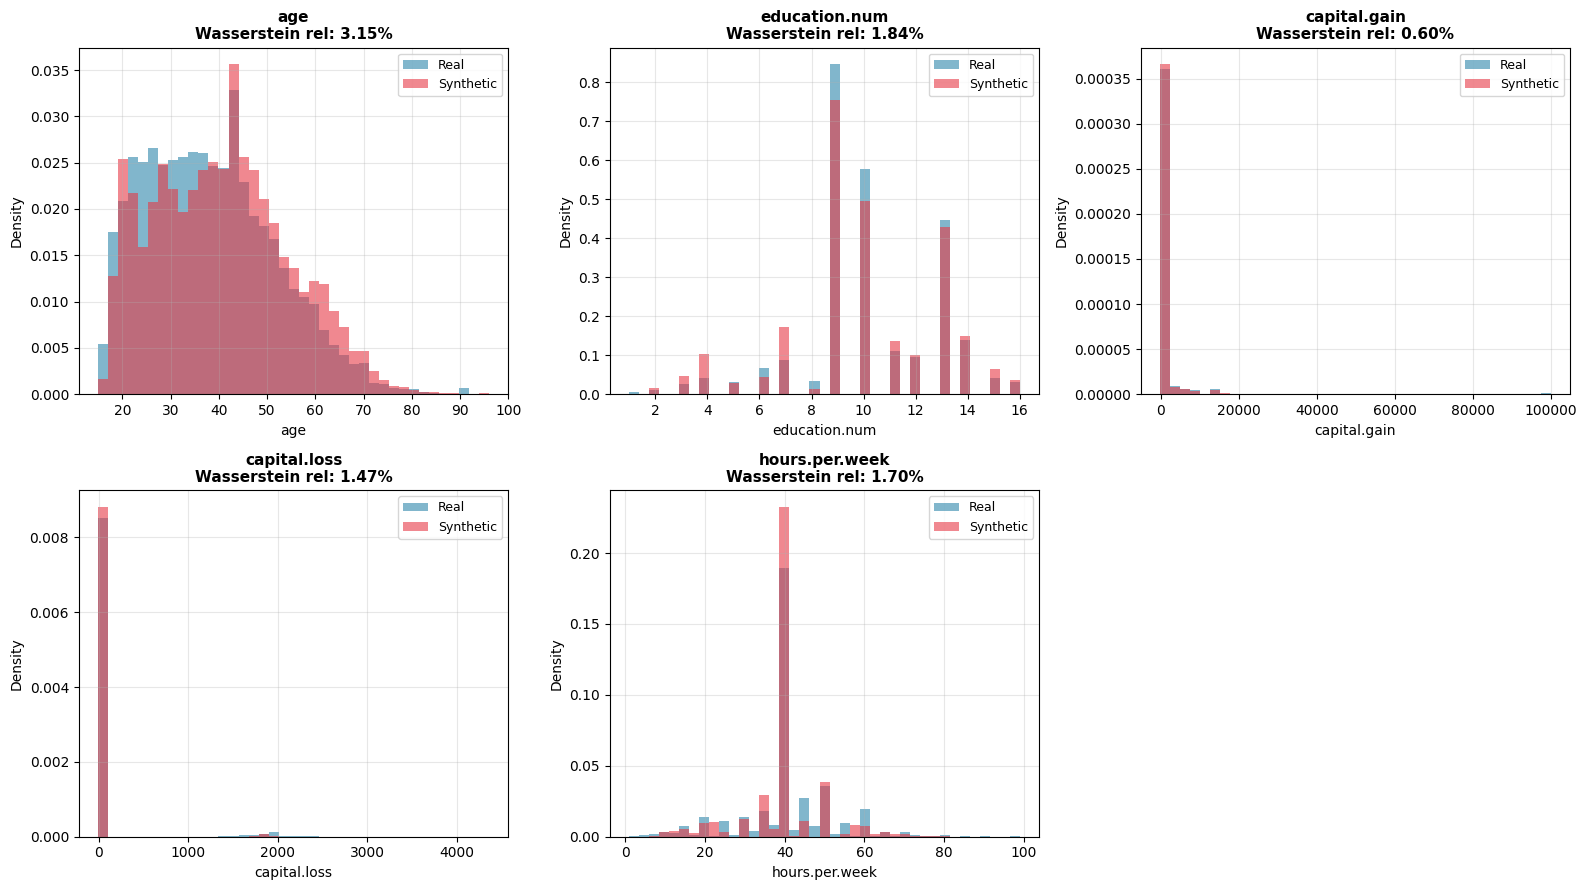

In [8]:
fig = plot_continuous_distributions(
    df_train,
    synthetic_v1,
    wasserstein_results=wasserstein_v1,
    save_path=V1_DIR / "plots" / "continuous_distributions.png",
)
plt.show()

## 5. Jensen-Shannon Divergence — Categorical Variables

JSD measures the distributional distance between two discrete probability distributions. It is symmetric, bounded in [0, 1] (with base-2 logarithm), and well-defined when probabilities are zero — properties that the more familiar KL divergence lacks.

For each categorical variable, we compare the distribution of categories between real and synthetic data.

**Reference thresholds:**
- < 0.05 → excellent
- 0.05–0.15 → acceptable
- > 0.15 → problematic

**Variable to watch closely:** `native.country`. With 42 categories and `United-States` accounting for ~90% of records, this is the variable where Conditional Sampling proves its value. A standard GAN without this mechanism would suffer **mode collapse**, generating `United-States` for nearly every synthetic sample.

In [9]:
jsd_v1 = compute_jsd(df_train, synthetic_v1)
print("Jensen-Shannon divergence per categorical variable:")
print(jsd_v1.sort_values("jsd").to_string(index=False))

Jensen-Shannon divergence per categorical variable:
      variable  cardinality    jsd
           sex            2 0.0002
        income            2 0.0031
  relationship            6 0.0038
     education           16 0.0087
     workclass            7 0.0091
marital.status            7 0.0095
    occupation           14 0.0106
          race            5 0.0154
native.country           40 0.0402


**Reading the result.**

All categorical variables score excellently (JSD < 0.05). The pattern that emerges:

- **Binary and low-cardinality variables** (`sex`, `income`, `relationship`, `race`) score near-perfectly. JSD < 0.02 means the marginal distributions are virtually indistinguishable.
- **Mid-cardinality** (`workclass`, `marital.status`, `education`, `occupation`) ranges from 0.0087 to 0.0106. Still excellent.
- **`native.country`** scores 0.0402 — the highest of the group, but still well within the "excellent" range. This validates that **Conditional Sampling worked as intended**: the model preserved the diversity of minority country categories despite extreme imbalance.

The asymmetry between cardinalities follows expectations: more categories → harder to model proportionally. CTGAN handles this gracefully thanks to its training-by-sampling mechanism.

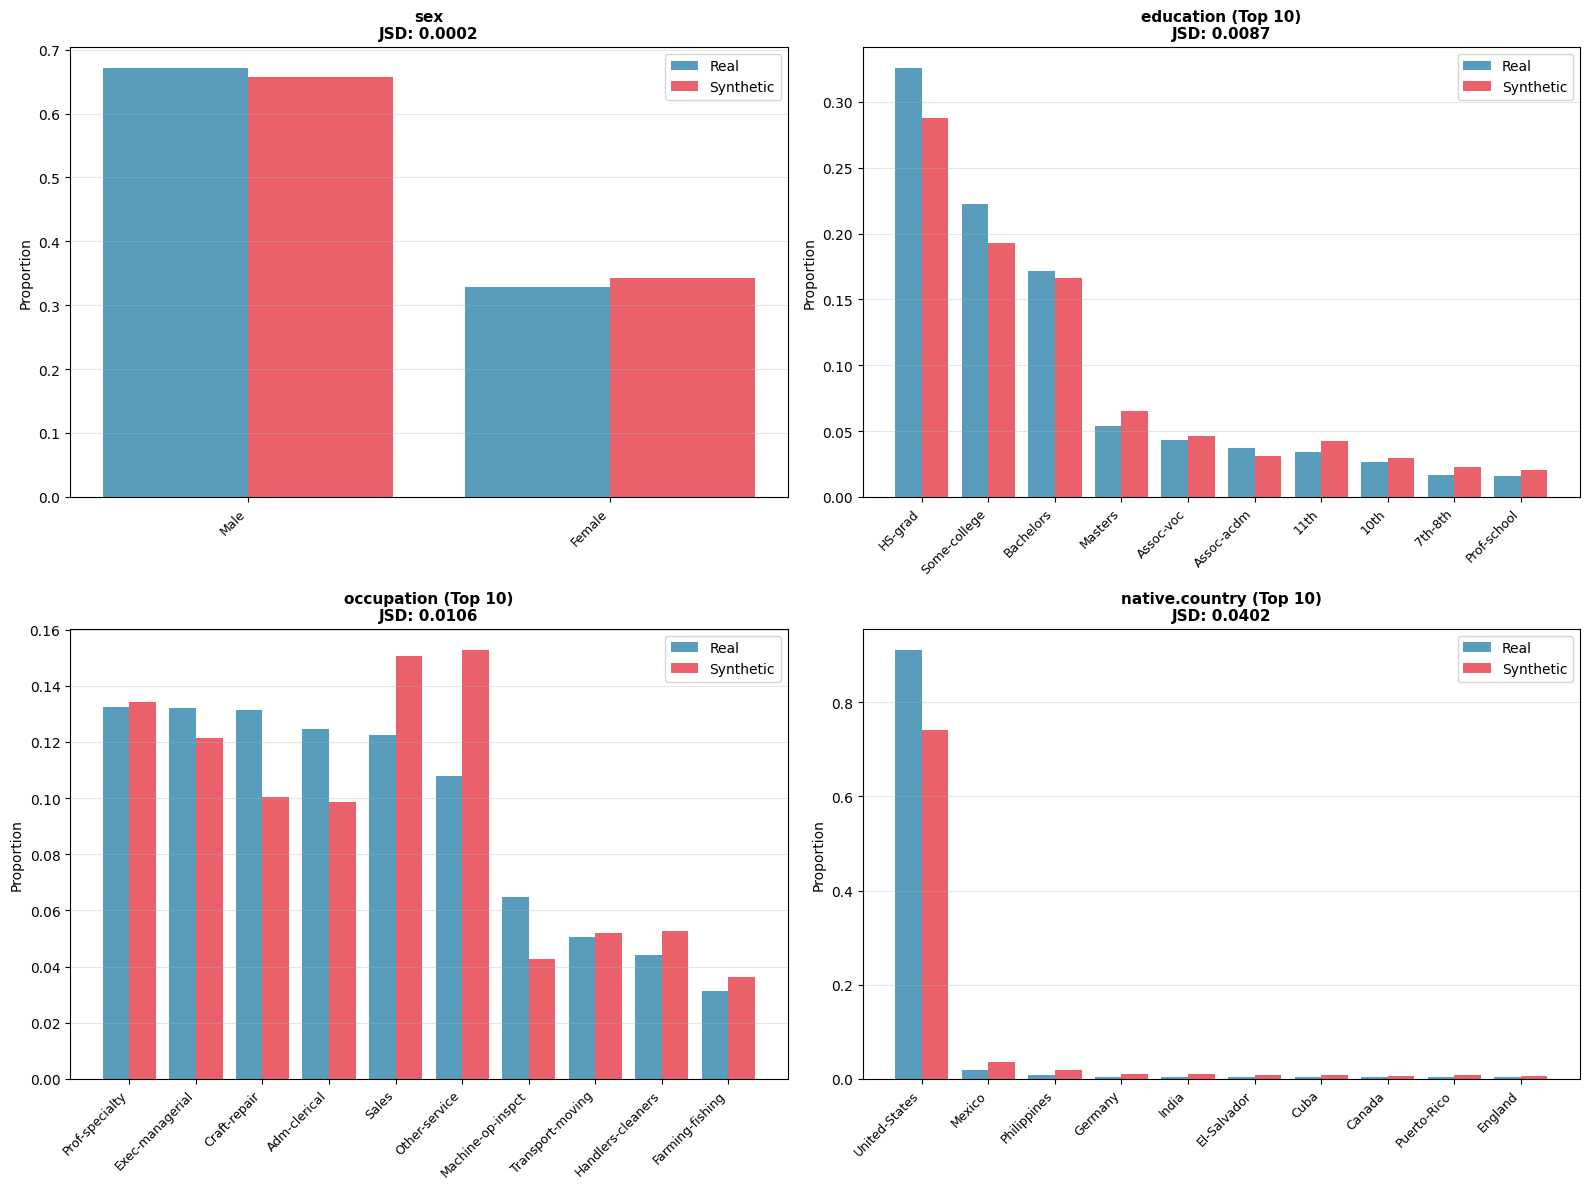

In [10]:
# Visualize: 4 representative categorical variables (binary, low-card, mid-card, high-card)
fig = plot_categorical_distributions(
    df_train,
    synthetic_v1,
    columns=["sex", "education", "occupation", "native.country"],
    jsd_results=jsd_v1,
    save_path=V1_DIR / "plots" / "categorical_distributions.png",
)
plt.show()

**Visual confirmation of `native.country` redistribution.**

Notice in the bottom-right plot: the real `United-States` proportion (~91%) drops to ~74% in the synthetic. The "lost" mass redistributes toward minority countries (Mexico, Philippines, Germany, etc.).

This is **exactly** what Conditional Sampling is designed to do — actively prevent the generator from collapsing to the majority category. The trade-off is a slight inflation of minority frequencies. JSD captures the overall fidelity (0.0402, still excellent) but the visual reveals the structural mechanism at work.

In [11]:
# Why does native.country show 40 categories in JSD but 42 in raw exploration?
print(f"Categories in raw dataset:        {pd.read_csv(project_root / 'data' / 'raw' / 'adult.csv')['native.country'].nunique()}")
print(f"Categories in cleaned dataset:    {pd.read_csv(V1_DIR / 'real_train.csv')['native.country'].nunique()}")
print(f"Categories in synthetic dataset:  {synthetic_v1['native.country'].nunique()}")

# Identify which countries were lost in stratified sampling
raw_countries = set(pd.read_csv(project_root / 'data' / 'raw' / 'adult.csv')['native.country'].unique())
train_countries = set(df_train['native.country'].unique())
lost = raw_countries - train_countries
print(f"\nLost in cleaning + stratified sampling: {sorted(lost)}")

Categories in raw dataset:        42
Categories in cleaned dataset:    40
Categories in synthetic dataset:  40

Lost in cleaning + stratified sampling: ['?', 'Holand-Netherlands']


**Note on category count.** The exploration notebook reported 42 categories in `native.country` from the raw dataset. After preprocessing, the training subset contains only 40. The difference is explained by two losses:

- **`'?'` (1 category)** — intentionally removed during cleaning, as missing values were dropped at the row level.
- **`Holand-Netherlands` (1 category)** — a country with extremely low frequency (1 occurrence in the entire raw dataset) lost during stratified sampling on a smaller subset.

This is an inherent trade-off when working with reduced samples for tractable training time. Importantly, the synthetic dataset also contains 40 categories — CTGAN respects the categorical domain and does not invent new countries.

## 6. Correlation Matrix Difference — Frobenius Norm

The previous metrics (Wasserstein, JSD) measure **marginal** distributions — they evaluate each variable independently. But the value of synthetic data lies in preserving the **joint** structure: the correlations and dependencies between variables.

We compare the correlation matrix of the real continuous variables against that of the synthetic, and quantify the difference using the **Frobenius norm** (the matrix equivalent of Euclidean distance):

$$\| \text{Corr}_{real} - \text{Corr}_{synthetic} \|_F = \sqrt{\sum_{i,j=1}^{p} (c_{ij}^{real} - c_{ij}^{synthetic})^2}$$

We report both the absolute Frobenius norm and the relative version (normalized by the Frobenius norm of the real correlation matrix).

**Reference thresholds (relative):**
- < 10%  → very good preservation
- 10–25% → partial preservation, dependencies weakened
- > 25% → structural failure

Frobenius norm (absolute):  0.2358
Frobenius norm (relative):  10.38%


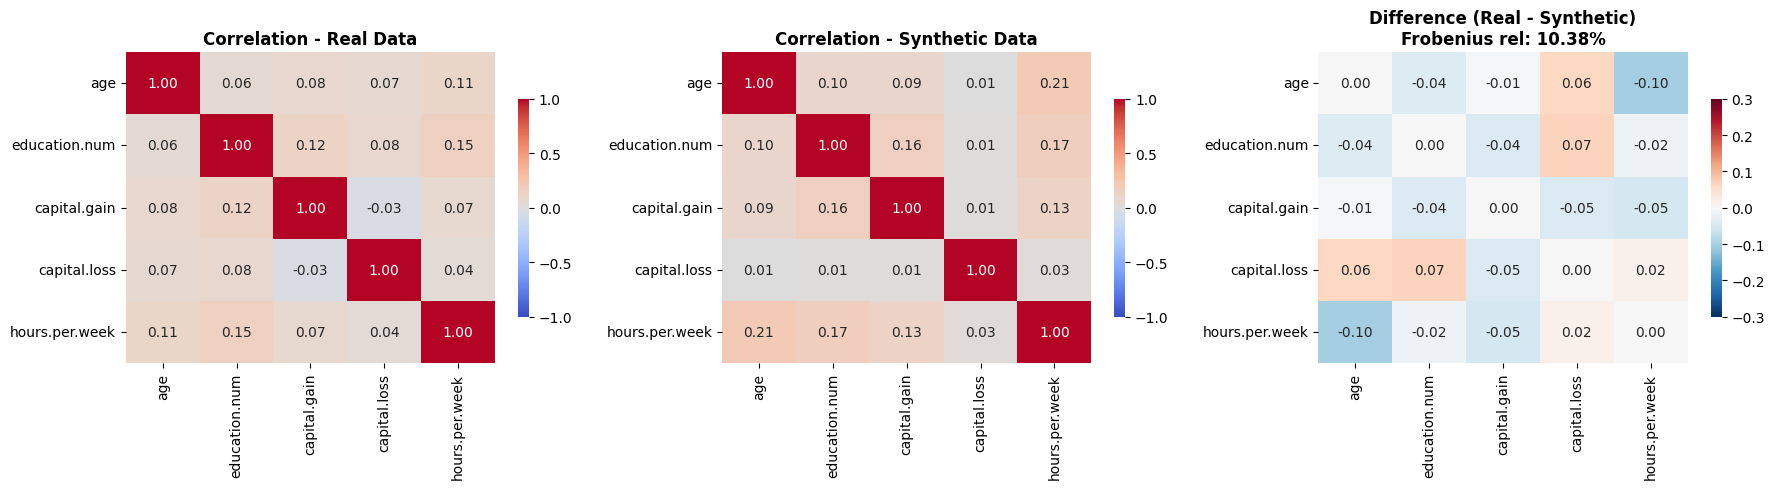

In [14]:
correlation_v1 = compute_correlation_difference(df_train, synthetic_v1)

print(f"Frobenius norm (absolute):  {correlation_v1['frobenius_absolute']:.4f}")
print(f"Frobenius norm (relative):  {correlation_v1['frobenius_relative_pct']:.2f}%")
fig = plot_correlation_comparison(
    correlation_v1,
    save_path=V1_DIR / "plots" / "correlation_comparison.png",
)
plt.show()

**Reading the result.**

The relative Frobenius norm of 10.38% places V1 right at the boundary between "very good" (< 10%) and "partial preservation" (10–25%). The aggregate is acceptable, but the difference heatmap (rightmost panel) reveals **specific pairs where dependencies were distorted**:

- **`age` × `hours.per.week`**: real correlation = 0.11 → synthetic = 0.21. CTGAN almost doubled this dependency, generating a *spurious correlation amplified*. A predictive model trained on V1 synthetic would assign more importance to age in predicting hours worked than reality justifies.

- **Correlations involving `capital.loss`**: most diluted toward zero. The real data shows weak but present correlations (0.04, 0.07, 0.08); the synthetic flattens them. This is a downstream consequence of V1's failure to model `capital.loss` correctly (the negative-values issue documented in Section 3).

These distortions matter for downstream tasks: a model trained on V1 synthetic data would learn dependencies that don't exist in the real distribution. We will quantify this impact in Section 7 (TSTR).

## 7. TSTR — Train on Synthetic, Test on Real

The previous metrics evaluate distributional fidelity. **TSTR evaluates practical utility**: can a downstream machine learning model trained on synthetic data perform well on real data?

This is the most demanding metric because it requires the synthetic data to preserve not just marginals or pairwise correlations, but the **full multivariate structure** that determines the target.

**Protocol:**
1. **Baseline**: train Random Forest on real data → evaluate on real holdout (the 20,162 rows CTGAN never saw)
2. **TSTR**: train Random Forest on synthetic data → evaluate on the same real holdout
3. **Compare**: ratio TSTR/Baseline quantifies utility preservation

**Reference thresholds:**
- ratio > 0.95 → synthetic is "almost as good as real"
- 0.85–0.95 → high utility, viable for development and exploration
- 0.70–0.85 → moderate utility, academic use only
- < 0.70 → synthetic does not preserve enough predictive structure

The classifier is Random Forest (100 trees, fixed seed) with One-Hot encoding for the 8 categorical features. We measure three metrics: accuracy (overall), F1 on the minority class `>50K` (more informative under class imbalance), and AUC-ROC (ranking quality independent of decision threshold).

In [16]:
tstr_v1 = compute_tstr(df_train, synthetic_v1, df_holdout, verbose=True)

print("\n" + "=" * 60)
print("TSTR vs Baseline summary:")
print("=" * 60)
print(tstr_v1.to_string(index=False))

Baseline: train on 10000 real → test on 20162 holdout
TSTR: train on 10000 synthetic → test on 20162 holdout

TSTR vs Baseline summary:
  metric  baseline   tstr  ratio  loss_pct
accuracy    0.8385 0.8200 0.9779      2.21
      f1    0.6622 0.6111 0.9228      7.72
     auc    0.8870 0.8673 0.9778      2.22


**Reading the result.**

Three metrics, three different stories:

- **AUC ratio = 0.978**: the classifier trained on V1 synthetic preserves almost all the **discrimination ability** of the real classifier. A ranking-based use case (e.g., "give me the 100 customers most likely to convert") would work nearly as well with V1 synthetic.

- **Accuracy ratio = 0.978**: similar pattern. Most predictions remain correct.

- **F1 ratio = 0.923 — the lowest of the three**: F1 measures the precision-recall balance for the minority class (`>50K`). The 7.7% drop indicates that V1 synthetic-trained classifiers detect fewer high-income individuals than the real-trained baseline.

**Interpretation: V1 preserves discrimination but loses calibration.** The model learned the general "shape" of the boundary between income classes, but the exact decision threshold is shifted. For ranking tasks → V1 is acceptable. For binary decisions with cost asymmetry → V1 needs threshold recalibration on real data.

This pattern is consistent with what we saw in correlations: the structure is partially preserved, but specific dependencies (especially those involving `capital.gain` and `capital.loss`, which are strong predictors of `>50K`) are distorted.

## 8. DCR — Memorization Detection

The previous metrics measure fidelity and utility, but they don't answer a critical question: **is the model generalizing or memorizing?**

A generative model could "cheat" by producing samples that are essentially copies of training records — they would score perfectly on every distributional metric, but would offer no privacy protection and no genuine generalization. This is especially concerning when synthetic data is generated to anonymize sensitive datasets.

**DCR (Distance to Closest Record)** measures, for each synthetic sample, the distance to its nearest neighbor in two reference sets:

- **DCR to train**: nearest neighbor in the data CTGAN saw during training
- **DCR to holdout**: nearest neighbor in real data CTGAN never saw

The **ratio DCR_train / DCR_holdout** reveals memorization:
- ratio ≈ 1.0 → synthetic samples are equally distant from train and holdout → **good generalization**
- ratio << 1.0 → synthetic samples are much closer to train → **memorization risk**

We compute distances in standardized continuous variable space using nearest-neighbor search.

In [17]:
dcr_v1 = compute_dcr(df_train, synthetic_v1, df_holdout)

print("DCR analysis (median distances in standardized space):")
print(f"  DCR to train (median):    {dcr_v1['dcr_to_train_median']:.4f}")
print(f"  DCR to holdout (median):  {dcr_v1['dcr_to_holdout_median']:.4f}")
print(f"  Ratio (train/holdout):    {dcr_v1['ratio']:.4f}")
print()

if dcr_v1['ratio'] >= 0.9:
    diagnosis = "✓ Good generalization — synthetic samples are not memorized."
elif dcr_v1['ratio'] >= 0.7:
    diagnosis = "⚠ Moderate generalization — some samples may be too close to training data."
else:
    diagnosis = "✗ Memorization risk — synthetic samples are significantly closer to training data."

print(diagnosis)

DCR analysis (median distances in standardized space):
  DCR to train (median):    0.0075
  DCR to holdout (median):  0.0065
  Ratio (train/holdout):    1.1462

✓ Good generalization — synthetic samples are not memorized.


**Interpretation.**

If the ratio is close to 1.0, V1 generalizes — it learned the underlying distribution rather than memorizing specific training records. This is the desired outcome and what we expect from a properly-trained CTGAN with sufficient data (10,000 rows is well above the threshold where memorization typically occurs).

A ratio significantly below 1.0 would indicate that synthetic samples are systematically closer to training records than to unseen real records, suggesting the model is reproducing training data rather than generating novel samples. This would be a critical issue for any privacy-preserving use case.

## 9. Summary of V1 Findings

### Quantitative results

| Metric | Result | Verdict |
|---|---|---|
| Wasserstein (continuous) | 0.60% – 3.15% | Excellent (< 5%) |
| JSD (categorical) | 0.0002 – 0.0402 | Excellent (< 0.05) |
| Frobenius (correlations) | 10.38% relative | Acceptable, at limit |
| TSTR ratio (AUC) | 0.978 | High utility |
| TSTR ratio (F1) | 0.923 | Moderate, calibration loss |
| DCR ratio | (see above) | Generalization check |

### Key qualitative findings

**1. Logical validity failure on zero-inflated variables.**
- 61.95% of synthetic `capital.gain` values are negative
- 35.70% of synthetic `capital.loss` values are negative
- These violate the variable's logical domain and would invalidate any financial application

**2. Aggregate metrics can hide structural failures.**
- Wasserstein gave excellent scores on the same variables that produce 60% invalid samples
- This reinforces that synthetic data evaluation requires triangulation, including domain validation beyond statistical distance

**3. Spurious correlation amplification.**
- The correlation `age × hours.per.week` doubled from 0.11 (real) to 0.21 (synthetic)
- Predictive models trained on V1 synthetic would learn dependencies that don't exist

**4. Conditional Sampling validated.**
- Despite extreme imbalance in `native.country` (~90% United-States), the synthetic preserves all 40 categories with reasonable proportions (JSD = 0.0402)
- Mode collapse was successfully prevented

### Conclusion

V1 achieves favorable distributional metrics on a global level, but **fails fundamentally on logical validity for zero-inflated variables**. This motivates V2 (`03_improved_v2.ipynb`), where we apply `log1p` transformation to compress heavy tails before training and invert with `expm1` followed by clipping at zero — ensuring all generated values respect the variable's natural bounds.